<a href="https://colab.research.google.com/github/detoma2158208-bit/progetto-intelligenza-artificiale-/blob/main/progetto_IAII_seconda_versione_corretta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESCRIZIONE DEL DATASET

##import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##caricamento file csv

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
dataset_path= "/content/drive/MyDrive/datasets (1)/"
df= pd.read_csv(dataset_path  + 'data.csv', index_col=None,header=0)
df.head()

,gender,C_api,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,...,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,male,1,2,2,20170527205915,20170721044501,543,56,43,...,4,0,0,91,28,6,76,324,0.915024,978
1,0,unknown,3,3,1,20110301072441,20170731213735,2764,2345,514,...,7,0,0,100,249,183,646,1526,0.661673,477
2,1,male,1,0,2,20060907204302,20140911191722,57,2927,25,...,0,0,0,3,0,1,3,49,0.800528,664
3,1,male,1,1,2,20121003144916,20121208180528,104,67,5,...,2,0,0,20,1,2,2,78,1.027717,841
4,0,unknown,3,1,1,20070311125035,20141106121057,184,2798,27,...,0,0,0,26,10,5,24,112,0.997535,994


## analisi della struttura del dataset

In [5]:
print ("osservazioni totali nel CSV: ", df.shape [0])
print ("osservazioni totali nel CVS: ", df.shape [1])

osservazioni totali nel CSV:  4746
osservazioni totali nel CVS:  21


--> il dataset presenta 4746 osservazioni e 21 colonne totali. queste 21 colonne sono composte da: 18 feature + 3 colonne di genere

In [6]:
df.dtypes

,0
gender,int64
C_api,object
C_man,int64
E_NEds,int64
E_Bpag,int64
firstDay,int64
lastDay,int64
NEds,int64
NDays,int64
NActDays,int64


In [7]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gender         4746 non-null   int64  
 1   C_api          4746 non-null   object 
 2   C_man          4746 non-null   int64  
 3   E_NEds         4746 non-null   int64  
 4   E_Bpag         4746 non-null   int64  
 5   firstDay       4746 non-null   int64  
 6   lastDay        4746 non-null   int64  
 7   NEds           4746 non-null   int64  
 8   NDays          4746 non-null   int64  
 9   NActDays       4746 non-null   int64  
 10  NPages         4746 non-null   int64  
 11  NPcreated      4746 non-null   int64  
 12  pagesWomen     4746 non-null   int64  
 13  wikiprojWomen  4746 non-null   int64  
 14  ns_user        4746 non-null   int64  
 15  ns_wikipedia   4746 non-null   int64  
 16  ns_talk        4746 non-null   int64  
 17  ns_userTalk    4746 non-null   int64  
 18  ns_conte

In [8]:
df.isnull().sum()

,0
gender,0
C_api,0
C_man,0
E_NEds,0
E_Bpag,0
firstDay,0
lastDay,0
NEds,0
NDays,0
NActDays,0


--> df.isnull().sum() mostra che non ci sono valori nulli per nessuna colonna presente nel dataset

## analisi iniziale della colonna target

In [9]:
df['gender'].value_counts ()
(df["gender"].value_counts(normalize=True)*100).round(2)

,proportion
gender,
1,58.83
0,33.73
2,7.44


--> Calcola la distribuzione delle classi di 'gender' in percentuale:

value_counts(normalize=True) dà le proporzioni, *100 le converte in %, round(2) arrotonda a 2 decimali.


In [10]:
df_known = df[df["gender"].isin([1,2])].copy()

df_known["gender"].value_counts()
(df_known["gender"].value_counts(normalize=True)*100).round(2)

,proportion
gender,
1,88.78
2,11.22


--> Crea un sotto-dataset con solo gender=1 (male) e gender=2 (female); .copy() evita warning quando lo modifichiamo.

Poi calcola distribuzione classi: prima i conteggi assoluti, poi le percentuali (normalize=True, *100, round(2)).


In [11]:
df.describe()

,gender,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
count,4746.000000,4746.000000,4746.000000,4746.000000,4.746000e+03,4.746000e+03,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000
mean,0.737042,2.082807,1.484197,1.646228,2.009942e+13,2.015489e+13,2029.969448,2036.607880,183.162663,689.451960,43.479140,0.438896,0.439949,74.372946,74.368310,49.947745,96.081753,1521.886641,1.000000,867.148546
std,0.585355,0.964978,1.099795,1.079263,3.516337e+10,1.748104e+10,7793.300833,1336.119914,374.034481,3355.302483,297.395507,5.327440,17.832244,246.407233,560.782479,215.554281,545.025818,6099.009235,0.325763,325.933076
min,0.000000,1.000000,0.000000,0.000000,2.002011e+13,2.012010e+13,50.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.411985,297.000000
25%,0.000000,1.000000,1.000000,1.000000,2.007042e+13,2.014070e+13,95.000000,835.250000,24.000000,29.000000,1.000000,0.000000,0.000000,4.000000,0.000000,0.000000,1.000000,61.000000,0.831954,664.000000
50%,1.000000,3.000000,1.000000,2.000000,2.009121e+13,2.016072e+13,218.000000,2035.500000,53.000000,68.000000,4.000000,0.000000,0.000000,14.000000,1.000000,4.000000,5.000000,151.000000,0.997535,917.000000
75%,1.000000,3.000000,2.000000,3.000000,2.013040e+13,2.017073e+13,757.750000,3146.500000,154.000000,219.750000,14.000000,0.000000,0.000000,46.000000,8.000000,19.000000,22.000000,563.750000,1.057149,994.000000
max,2.000000,3.000000,3.000000,3.000000,2.017093e+13,2.017100e+13,153193.000000,5349.000000,3843.000000,94142.000000,13394.000000,185.000000,949.000000,6041.000000,24392.000000,4788.000000,12350.000000,115547.000000,1.865008,1596.000000


#DATA CLEANING E PREPARAZIONE INIZIALE

##conversione date

In [12]:
df['firstDay'] = pd.to_datetime(df['firstDay'].astype(str), format='%Y%m%d%H%M%S')
df.head()

,gender,C_api,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,...,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,male,1,2,2,2017-05-27 20:59:15,20170721044501,543,56,43,...,4,0,0,91,28,6,76,324,0.915024,978
1,0,unknown,3,3,1,2011-03-01 07:24:41,20170731213735,2764,2345,514,...,7,0,0,100,249,183,646,1526,0.661673,477
2,1,male,1,0,2,2006-09-07 20:43:02,20140911191722,57,2927,25,...,0,0,0,3,0,1,3,49,0.800528,664
3,1,male,1,1,2,2012-10-03 14:49:16,20121208180528,104,67,5,...,2,0,0,20,1,2,2,78,1.027717,841
4,0,unknown,3,1,1,2007-03-11 12:50:35,20141106121057,184,2798,27,...,0,0,0,26,10,5,24,112,0.997535,994


In [13]:
df['lastDay'] = pd.to_datetime(df['lastDay'].astype(str), format='%Y%m%d%H%M%S')
df.head()

,gender,C_api,C_man,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,...,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,male,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,...,4,0,0,91,28,6,76,324,0.915024,978
1,0,unknown,3,3,1,2011-03-01 07:24:41,2017-07-31 21:37:35,2764,2345,514,...,7,0,0,100,249,183,646,1526,0.661673,477
2,1,male,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,...,0,0,0,3,0,1,3,49,0.800528,664
3,1,male,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,...,2,0,0,20,1,2,2,78,1.027717,841
4,0,unknown,3,1,1,2007-03-11 12:50:35,2014-11-06 12:10:57,184,2798,27,...,0,0,0,26,10,5,24,112,0.997535,994


##rimozione colonne inutili

In [14]:
df2 = df.drop(columns= ['C_api', 'C_man'])
df2.head ()

,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,204,4,0,0,91,28,6,76,324,0.915024,978
1,0,3,1,2011-03-01 07:24:41,2017-07-31 21:37:35,2764,2345,514,722,7,0,0,100,249,183,646,1526,0.661673,477
2,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,25,0,0,0,3,0,1,3,49,0.800528,664
3,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,66,2,0,0,20,1,2,2,78,1.027717,841
4,0,1,1,2007-03-11 12:50:35,2014-11-06 12:10:57,184,2798,27,125,0,0,0,26,10,5,24,112,0.997535,994


--> abbiamo deciso di eliminare due colonne: C_api, C_man

##creazione df2_known e separazione unkown

In [15]:
# 1 = male, 2 = female
df2_known = df2[df2["gender"].isin([1, 2])].copy()
df2_known.head (100)

,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,204,4,0,0,91,28,6,76,324,0.915024,978
2,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,25,0,0,0,3,0,1,3,49,0.800528,664
3,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,66,2,0,0,20,1,2,2,78,1.027717,841
5,1,3,1,2006-05-26 14:19:42,2017-09-14 13:19:32,1887,4130,197,510,62,0,0,7,2,31,10,1660,0.661673,477
7,1,3,3,2008-11-05 22:48:14,2017-08-18 01:29:59,5833,3209,566,376,108,0,0,161,10,9,184,4744,1.481654,1596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,1,1,2,2011-04-05 14:10:56,2017-08-20 21:43:28,121,2330,37,57,1,0,0,30,6,8,2,57,1.027717,841
158,2,1,1,2016-10-20 07:55:33,2017-05-15 18:49:17,109,208,19,9,0,0,0,91,0,1,13,4,0.997535,994
159,2,0,0,2005-05-23 11:01:05,2012-05-27 18:22:51,88,2562,15,11,2,0,0,2,0,1,2,83,1.865008,1277
160,1,0,3,2017-02-04 14:14:33,2017-02-06 18:04:26,61,3,3,3,1,0,0,60,0,0,0,1,0.411985,297


In [16]:
df2_unknown = df2[df2["gender"] == 0]
df2_unknown.head ()

,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
1,0,3,1,2011-03-01 07:24:41,2017-07-31 21:37:35,2764,2345,514,722,7,0,0,100,249,183,646,1526,0.661673,477
4,0,1,1,2007-03-11 12:50:35,2014-11-06 12:10:57,184,2798,27,125,0,0,0,26,10,5,24,112,0.997535,994
6,0,0,1,2013-07-22 23:41:49,2013-07-31 13:06:29,57,10,7,13,1,0,0,10,0,4,6,37,1.057149,1074
10,0,1,3,2011-05-10 15:53:59,2016-09-21 11:24:01,160,1962,40,42,0,0,0,36,0,34,28,60,0.594368,493
14,0,0,2,2010-10-13 09:16:09,2015-07-27 12:18:54,81,1749,38,34,0,0,0,33,0,0,0,30,0.800528,664


##controllo dimensioni e colonne df2_known contiene solo gender = 1 (male) e gender = 2 (female)

In [38]:
print("Osservazioni (righe):", df2_known.shape[0])
print("Colonne totali:", df2_known.shape[1])
print("Colonne:", df2_known.columns)

Osservazioni (righe): 3145
Colonne totali: 19
Colonne: Index(['gender', 'E_NEds', 'E_Bpag', 'firstDay', 'lastDay', 'NEds', 'NDays',
       'NActDays', 'NPages', 'NPcreated', 'pagesWomen', 'wikiprojWomen',
       'ns_user', 'ns_wikipedia', 'ns_talk', 'ns_userTalk', 'ns_content',
       'weightIJ', 'NIJ'],
      dtype='object')


--> abbiamo deciso di lavorare su due dataset distinti: uno con gli unknown e uno con male/female

##definizioni X e y iniziali

In [17]:
y = df2_known["gender"]
X = df2_known.drop(columns=["gender"])
y.head (100)

,gender
0,1
2,1
3,1
5,1
7,1
...,...
157,1
158,2
159,2
160,1


--> creo X e y SOLO per known

y = target (nel nostro caso gender)

X = feature (altre colonne del dataset)

#EDA: analisi esplorativa dei dati

##distribuzione target

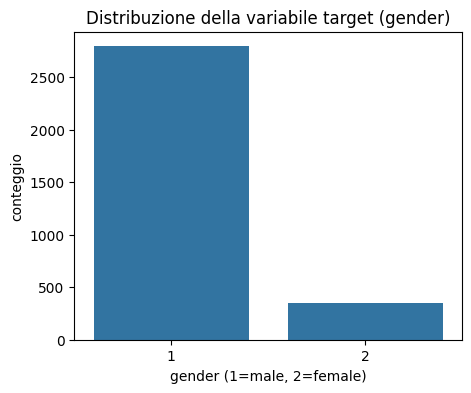

In [22]:
plt.figure(figsize=(5,4))
sns.countplot(x='gender', data=df2_known)
plt.title("Distribuzione della variabile target (gender)")
plt.xlabel("gender (1=male, 2=female)")
plt.ylabel("conteggio")
plt.show()

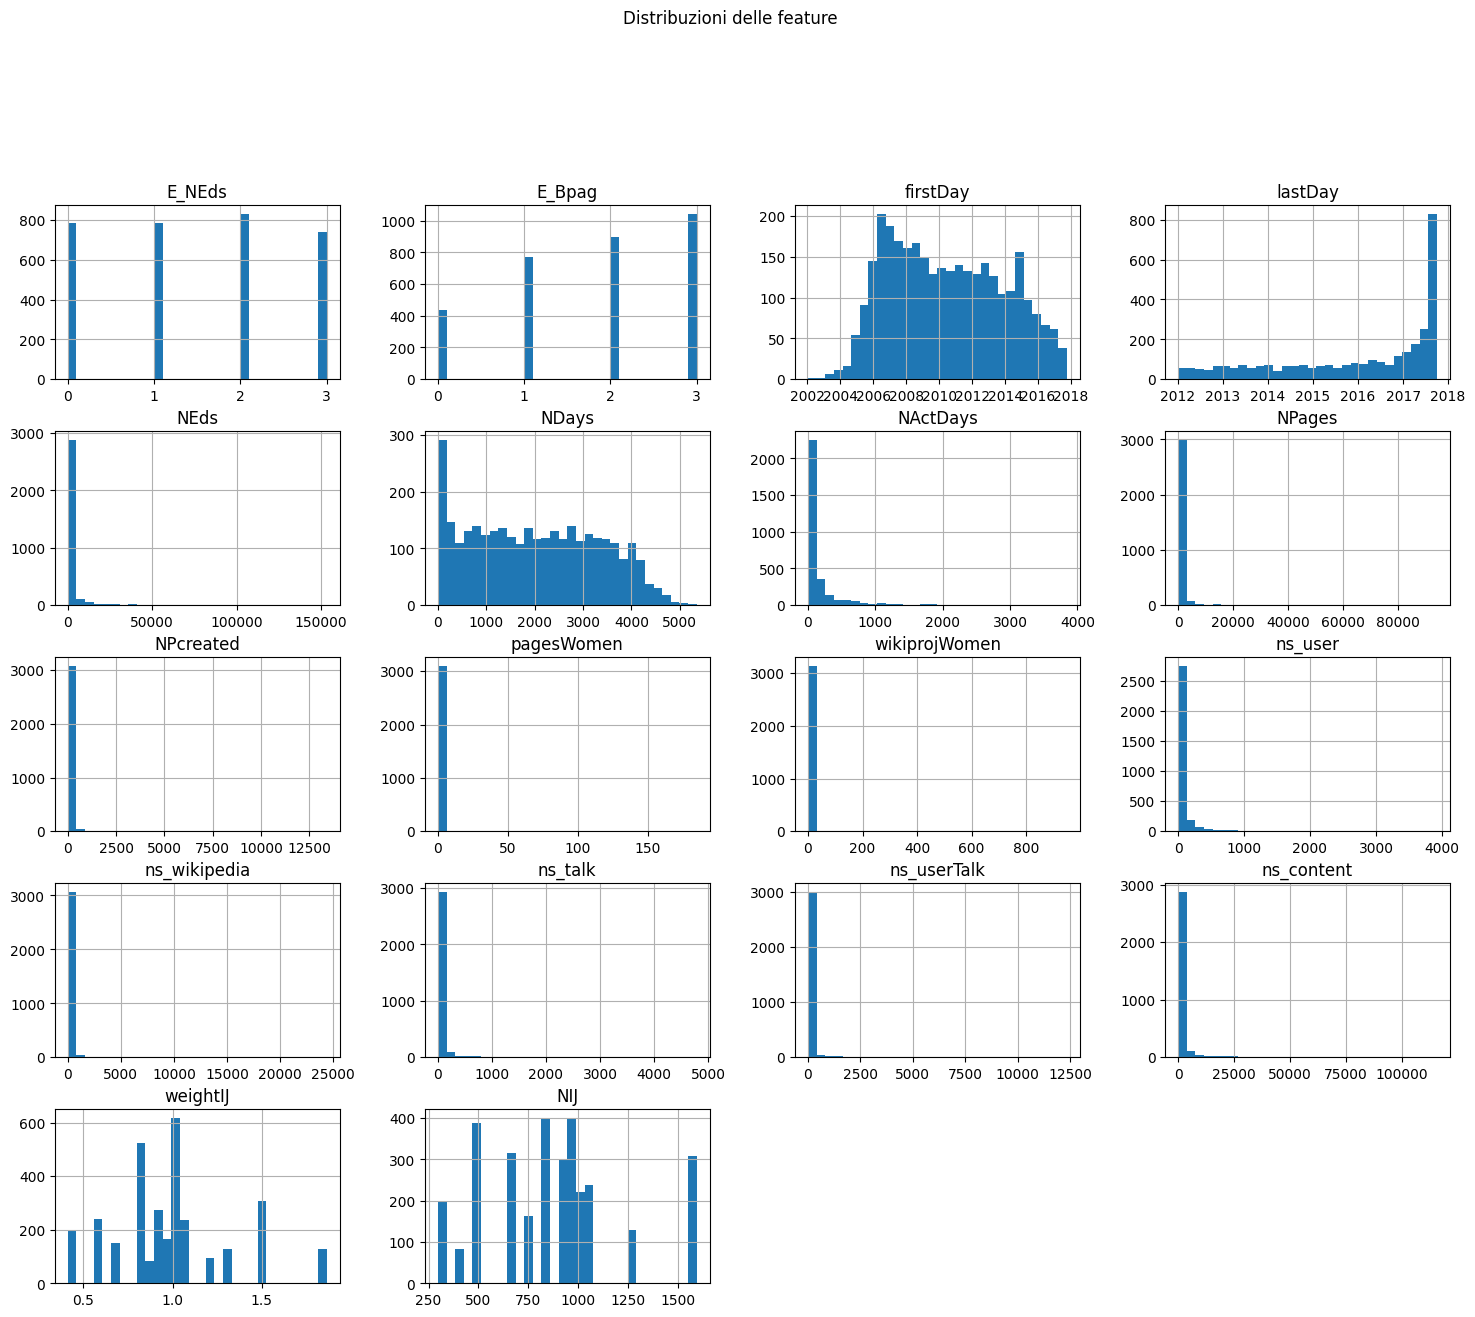

In [23]:
df2_known.drop(columns=['gender']).hist(figsize=(18,14), bins=30)
plt.suptitle("Distribuzioni delle feature", y=1.02)
plt.show()

##istogrammi e boxplot delle feature

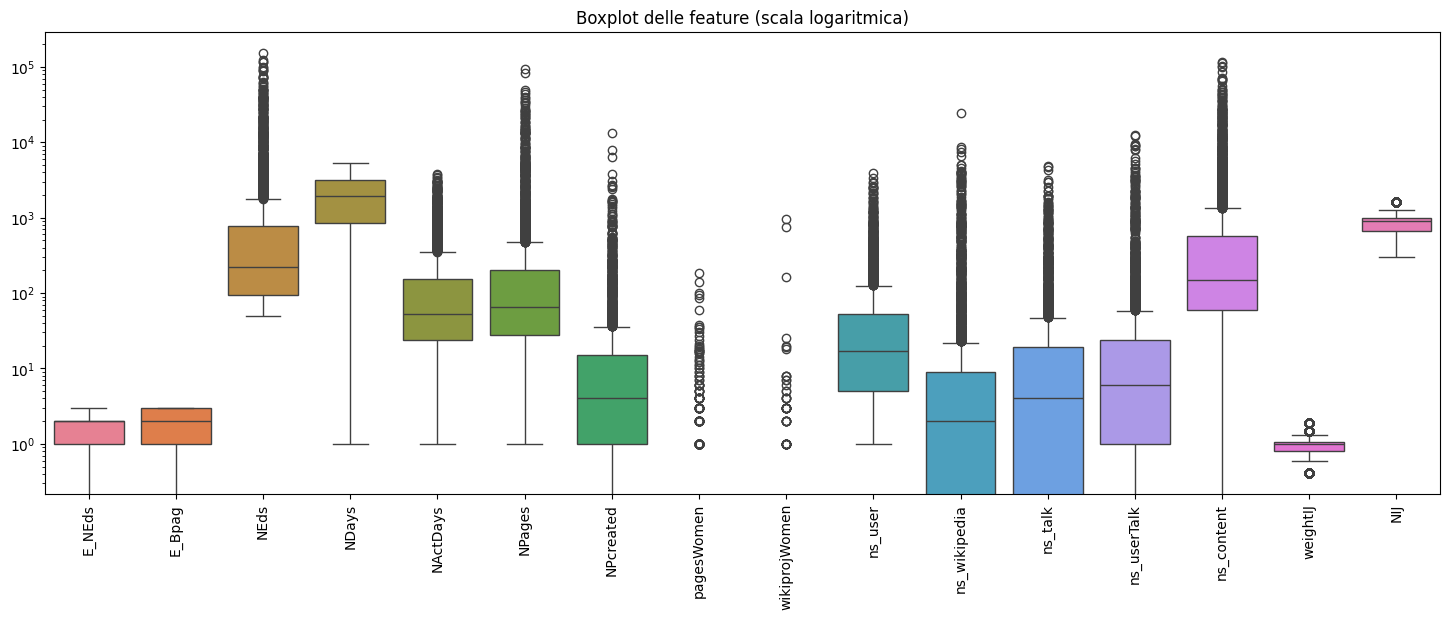

In [24]:
plt.figure(figsize=(18,6))
sns.boxplot(data=df2_known.drop(columns=['gender']))
plt.yscale("log")
plt.xticks(rotation=90)
plt.title("Boxplot delle feature (scala logaritmica)")
plt.show()

--> Boxplot delle feature (scala logaritmica)
La scala log aiuta a visualizzare meglio outlier/code lunghe nei conteggi

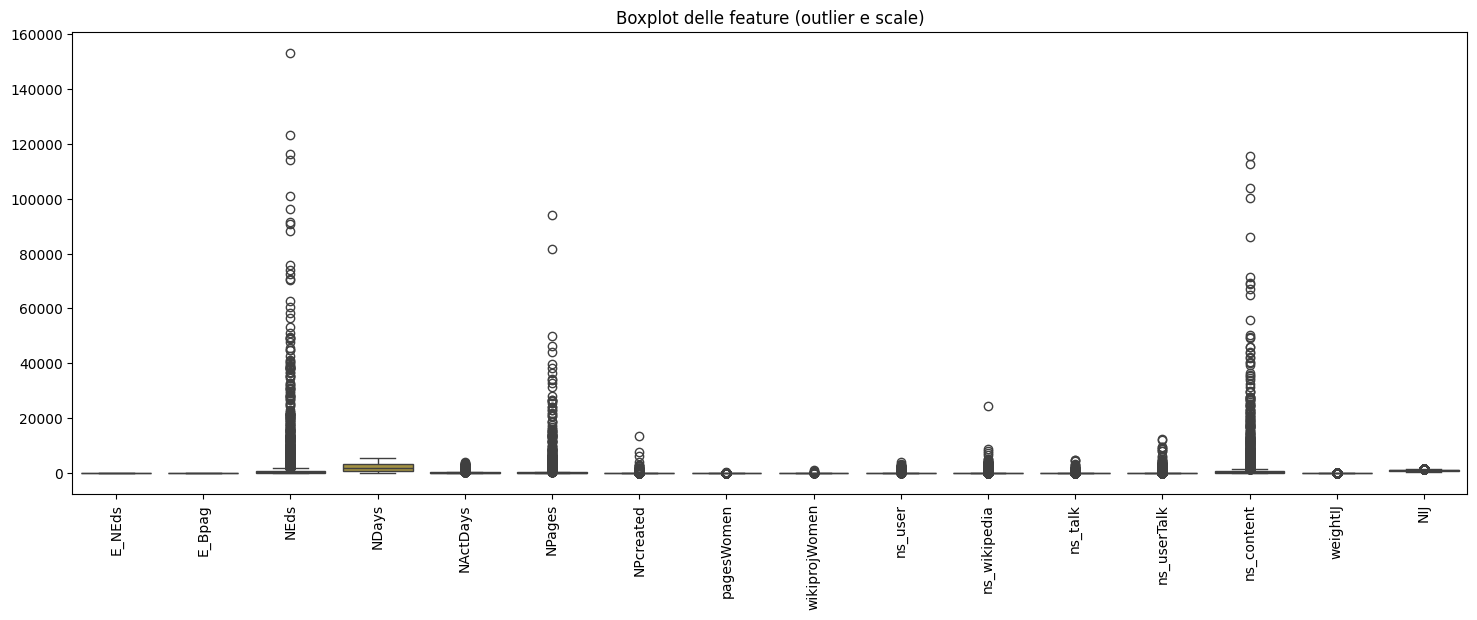

In [25]:
plt.figure(figsize=(18,6))
sns.boxplot(data=df2_known.drop(columns=['gender']))
plt.xticks(rotation=90)
plt.title("Boxplot delle feature (outlier e scale)")
plt.show()

--> Boxplot delle feature (scala lineare)
Serve per notare variabili con scale molto diverse e outlier estremi

##matrice di correlazioni generale

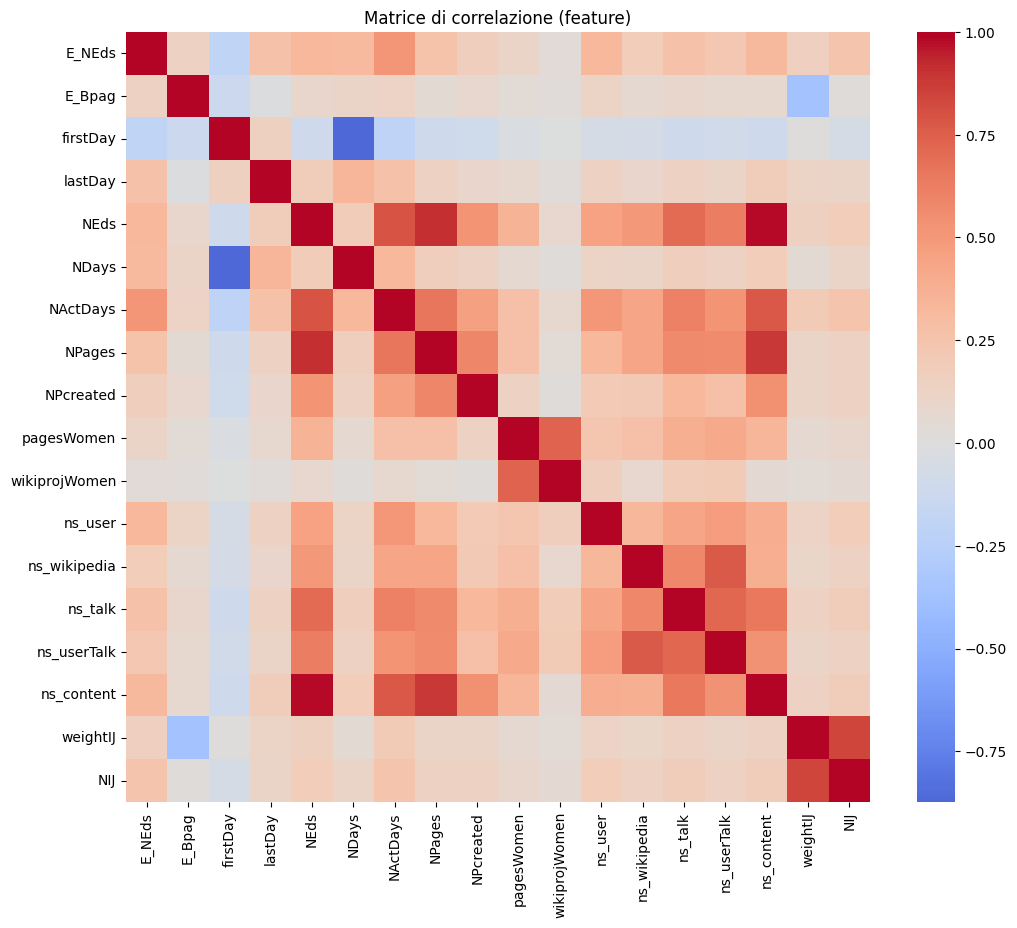

In [26]:
corr = df2_known.drop(columns=['gender']).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione (feature)")
plt.show()

--> Matrice di correlazione
Evidenzia coppie di feature fortemente correlate (ridondanza)

##scatterplot e boxplot di relazioni specifiche

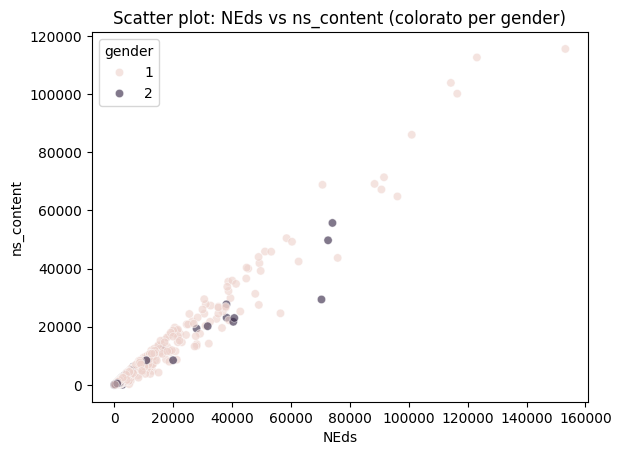

In [27]:
sns.scatterplot(
    x='NEds',
    y='ns_content',
    hue='gender',
    data=df2_known,
    alpha=0.6
)
plt.title("Scatter plot: NEds vs ns_content (colorato per gender)")
plt.show()

--> Scatterplot: esempio di relazione tra due feature (colorato per gender)
Nota: qui stiamo plottando NEds vs ns_content (non NPages)

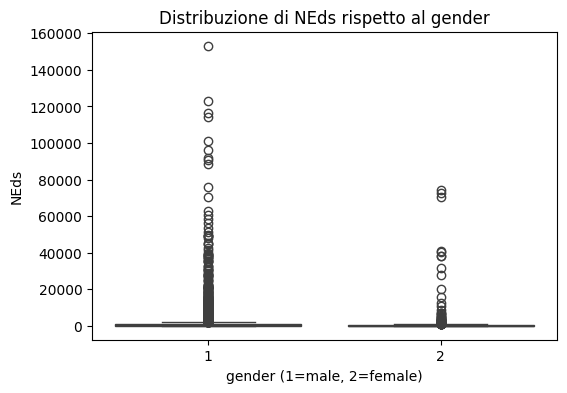

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(x='gender', y='NEds', data=df2_known)
plt.title("Distribuzione di NEds rispetto al gender")
plt.xlabel("gender (1=male, 2=female)")
plt.show()

--> Boxplot di una feature chiave rispetto al target
Serve per vedere se la distribuzione di NEds cambia tra male e female

#FEATURE ENGENEERING E SELEZIONE

##standardizzazione

In [39]:
from sklearn.preprocessing import StandardScaler
X = df2_known.drop(columns=['gender', 'firstDay', 'lastDay'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df2_known.head()


,gender,E_NEds,E_Bpag,firstDay,lastDay,NEds,NDays,NActDays,NPages,NPcreated,pagesWomen,wikiprojWomen,ns_user,ns_wikipedia,ns_talk,ns_userTalk,ns_content,weightIJ,NIJ
0,1,2,2,2017-05-27 20:59:15,2017-07-21 04:45:01,543,56,43,204,4,0,0,91,28,6,76,324,0.915024,978
2,1,0,2,2006-09-07 20:43:02,2014-09-11 19:17:22,57,2927,25,25,0,0,0,3,0,1,3,49,0.800528,664
3,1,1,2,2012-10-03 14:49:16,2012-12-08 18:05:28,104,67,5,66,2,0,0,20,1,2,2,78,1.027717,841
5,1,3,1,2006-05-26 14:19:42,2017-09-14 13:19:32,1887,4130,197,510,62,0,0,7,2,31,10,1660,0.661673,477
7,1,3,3,2008-11-05 22:48:14,2017-08-18 01:29:59,5833,3209,566,376,108,0,0,161,10,9,184,4744,1.481654,1596


--> Costruzione delle feature X per ML/EDA (togliamo target e date grezze)
- gender è il target
- firstDay e lastDay sono date grezze: per EDA le togliamo perché abbiamo già NDays/NActDays

##train_test_split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

--> divisione in Training set e Test set


##analisi importanza feature con Random Forest

Classifica importanza feature (relazioni non lineari incluse):
          Feature  Importance
3           NDays    0.138349
5          NPages    0.120399
4        NActDays    0.096221
13     ns_content    0.090322
2            NEds    0.082816
9         ns_user    0.079452
12    ns_userTalk    0.066563
8   wikiprojWomen    0.057964
10   ns_wikipedia    0.056467
11        ns_talk    0.054045
6       NPcreated    0.051577
15            NIJ    0.034347
14       weightIJ    0.028829
1          E_Bpag    0.023213
7      pagesWomen    0.009951
0          E_NEds    0.009484


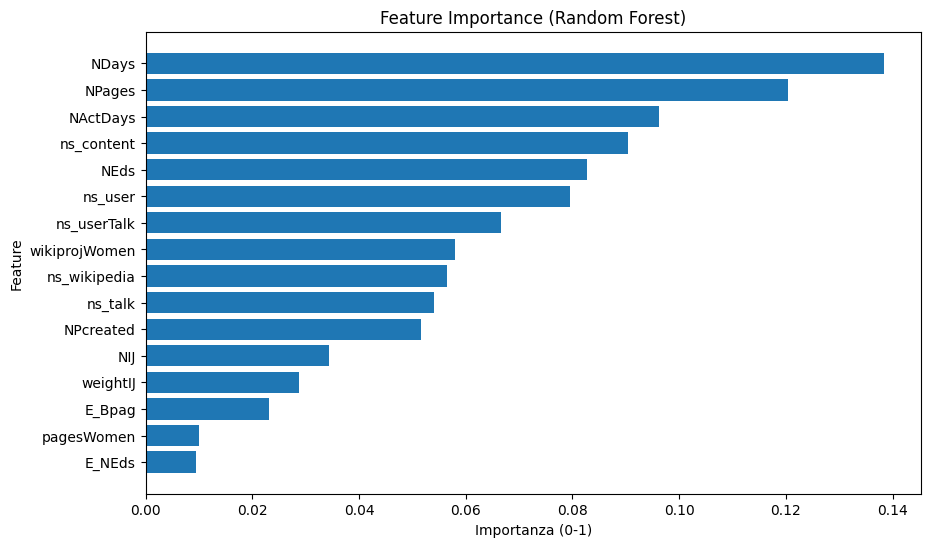

In [30]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Inizializzazione del modello
# n_estimators=100 crea 100 alberi decisionali
# random_state=42 garantisce che il risultato sia riproducibile
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Addestramento (Fit) SOLO sul Training Set
# Qui il modello impara le relazioni non lineari tra X_train e y_train
rf.fit(X_train, y_train)

# 3. Estrazione dell'importanza delle feature
# I valori sommano a 1. Più alto è il valore, più forte è la relazione.
importances = rf.feature_importances_

# 4. Creazione di un DataFrame per visualizzare i risultati
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Classifica importanza feature (relazioni non lineari incluse):")
print(feature_imp_df)

# (Opzionale) Visualizzazione grafica
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'])
plt.xlabel('Importanza (0-1)')
plt.ylabel('Feature')
plt.title('Feature Importance (Random Forest)')
plt.gca().invert_yaxis() # Inverte l'asse y per avere la feature più importante in alto
plt.show()

--> random forest solo su training set per visualizzare correlazioni

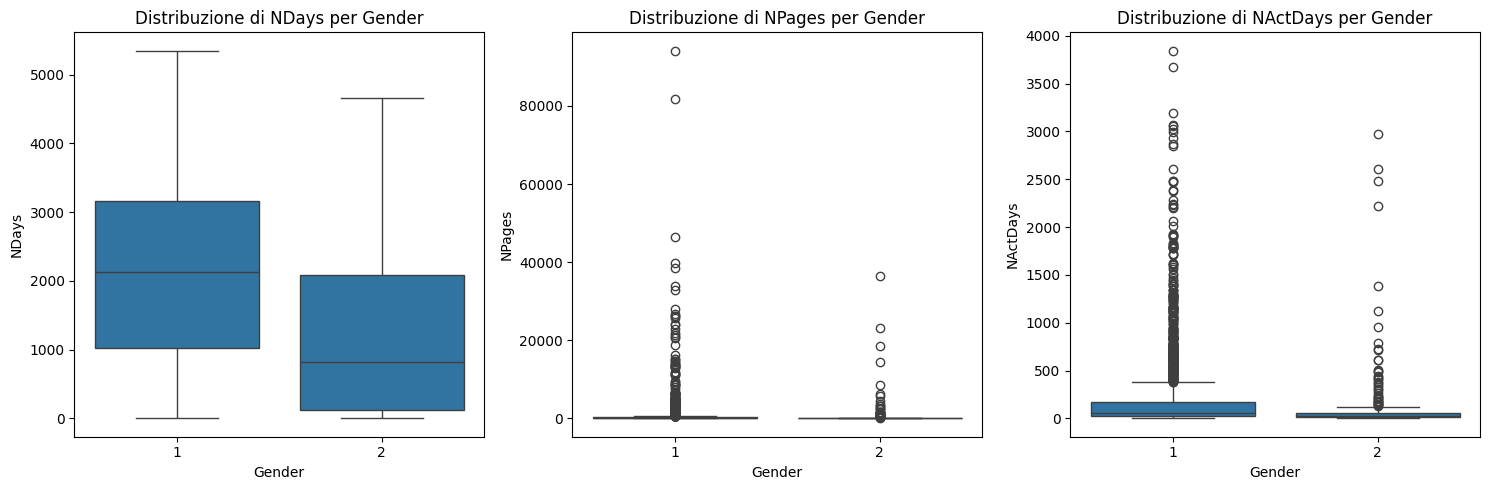

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selezioniamo le top 3 feature per l'analisi
top_features = ['NDays', 'NPages', 'NActDays']

# Impostiamo lo stile grafico
plt.figure(figsize=(15, 5))

for i, feature in enumerate(top_features):
    plt.subplot(1, 3, i+1) # Crea 3 grafici affiancati

    # Boxplot: Mostra la mediana e i quartili per ogni genere
    sns.boxplot(x=y_train, y=X_train[feature])

    plt.title(f'Distribuzione di {feature} per Gender')
    plt.xlabel('Gender')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

##matrice di correlazione tra le top 11 feature

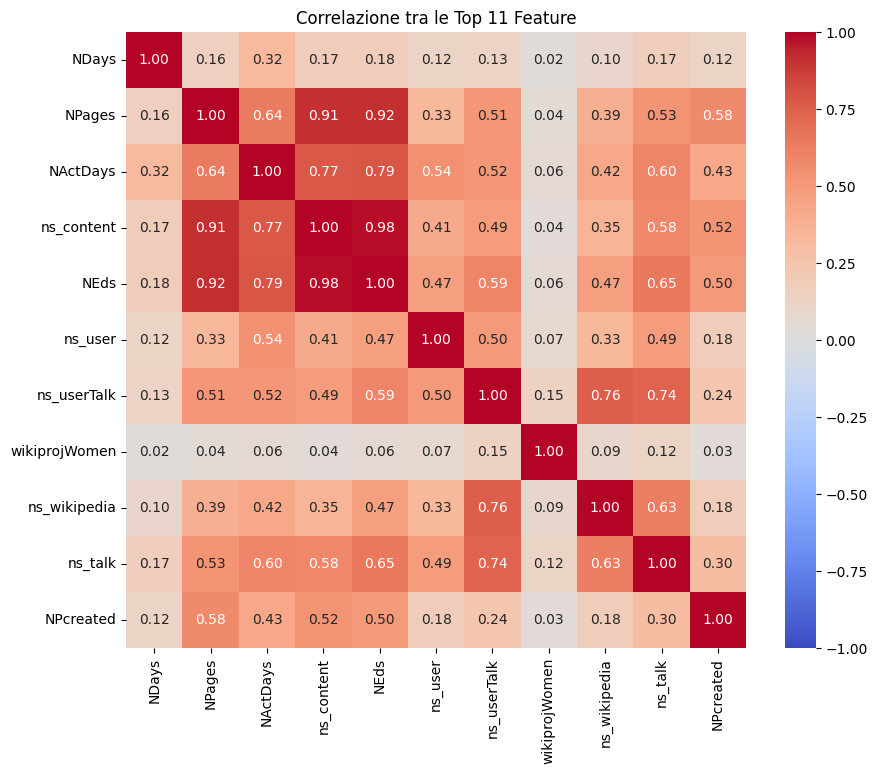

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista delle feature selezionate (Top 11)
selected_features = [
    'NDays', 'NPages', 'NActDays', 'ns_content', 'NEds',
    'ns_user', 'ns_userTalk', 'wikiprojWomen',
    'ns_wikipedia', 'ns_talk', 'NPcreated'
]

# Calcolo della matrice di correlazione solo su queste
corr_matrix = X_train[selected_features].corr()

# Visualizzazione
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlazione tra le Top 11 Feature')
plt.show()

##rimozione feature non correlate o ridondanti

In [33]:
import pandas as pd
import numpy as np

# --- PASSO 1: Definizione della funzione di pulizia (Il "Tool") ---
def remove_highly_correlated_features(X_train, feature_importance_df, threshold=0.95):
    # Calcolo matrice correlazione
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = set()

    for column in upper.columns:
        # Trova feature correlate sopra la soglia
        correlated_features = upper.index[upper[column] > threshold].tolist()

        for feature in correlated_features:
            # Recupera importanza
            imp_col = feature_importance_df.loc[feature_importance_df['Feature'] == column, 'Importance'].values[0]
            imp_feat = feature_importance_df.loc[feature_importance_df['Feature'] == feature, 'Importance'].values[0]

            # Decide chi eliminare
            if imp_col < imp_feat:
                print(f"Elimino '{column}' (conflitto con '{feature}')")
                to_drop.add(column)
            else:
                print(f"Elimino '{feature}' (conflitto con '{column}')")
                to_drop.add(feature)

    return list(to_drop)

# --- PASSO 2: Selezione delle Top 11 (L' "Imbuto") ---
top_11_features = [
    'NDays', 'NPages', 'NActDays', 'ns_content', 'NEds',
    'ns_user', 'ns_userTalk', 'wikiprojWomen', 'ns_wikipedia',
    'ns_talk', 'NPcreated'
]

# Creiamo il subset solo con le 11 migliori
X_train_sub = X_train[top_11_features].copy()
X_test_sub = X_test[top_11_features].copy()

print(f"1. Shape iniziale (Top 11): {X_train_sub.shape}")

# --- PASSO 3: Rimozione Automatica Doppioni ---
# Applichiamo la funzione SOLO sul subset
features_to_drop = remove_highly_correlated_features(X_train_sub, feature_imp_df, threshold=0.95)

# Creiamo i dataset finali
X_train_final = X_train_sub.drop(columns=features_to_drop)
X_test_final = X_test_sub.drop(columns=features_to_drop)

print(f"2. Shape finale: {X_train_final.shape}")
print(f"Feature rimaste ({len(X_train_final.columns)}): {X_train_final.columns.tolist()}")

1. Shape iniziale (Top 11): (2516, 11)
Elimino 'NEds' (conflitto con 'ns_content')
2. Shape finale: (2516, 10)
Feature rimaste (10): ['NDays', 'NPages', 'NActDays', 'ns_content', 'ns_user', 'ns_userTalk', 'wikiprojWomen', 'ns_wikipedia', 'ns_talk', 'NPcreated']


In [40]:
X_train_final.head()

,NDays,NPages,NActDays,ns_content,ns_user,ns_userTalk,wikiprojWomen,ns_wikipedia,ns_talk,NPcreated
3984,1713,516,298,1141,1498,634,0,211,59,28
1131,973,22,20,57,12,10,0,0,0,4
2231,2948,218,84,555,4,1,0,13,7,72
1836,2290,1306,1207,12593,234,79,0,59,59,36
325,2861,326,210,890,74,16,0,4,27,29
